In [ ]:
#Aishwarya Gandhi.M
#AMB2011

In [ ]:
import tensorflow as tf
mnist=tf.keras.datasets.mnist
(X_train,y_train),(X_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("Train images shape:",X_train.shape)
print("Train label shape:",y_test.shape)
print("Test images shape:",X_test.shape)
print("Test label shape:",y_test.shape)

Train images shape: (60000, 28, 28)
Train label shape: (10000,)
Test images shape: (10000, 28, 28)
Test label shape: (10000,)


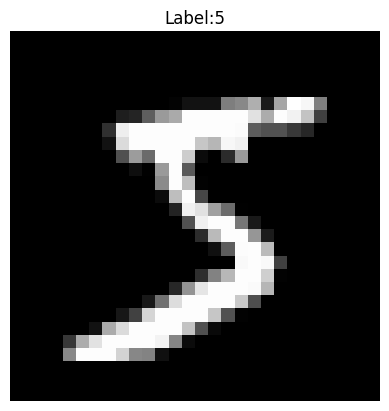

In [ ]:
import matplotlib.pyplot as plt
#Plot first images
plt.imshow(X_train[0],cmap='gray')
plt.title(f"Label:{y_train[0]}")   #show the label
plt.axis('off')
plt.show()

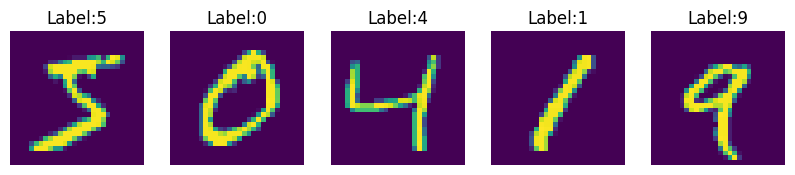

In [ ]:
#show first 5 images with labels
plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(X_train[i])
  plt.title(f"Label:{y_train[i]}")
  plt.axis('off')
plt.show()

In [ ]:
#step2:normalization of values(0 to 1)
train_images=X_train/255.0
test_images=X_test/255.0

In [ ]:
#step3:Add channel dimension(important for CMN)
train_images=train_images.reshape((60000,28,28,1))
test_images=test_images.reshape((10000,28,28,1))

In [ ]:
from tensorflow.keras import layers,models

model=models.Sequential([
    layers.Conv2D(16,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(32,activation='relu'),
    layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#step5:Compile method
model.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
#step6:Train model
model.fit(train_images,y_train,epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9402 - loss: 0.2079
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9775 - loss: 0.0752
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9831 - loss: 0.0538


In [ ]:
#step7:Test model
test_loss,test_acc=model.evaluate(test_images,y_test)
print("Accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9797 - loss: 0.0607
Accuracy: 0.9797000288963318


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Original Label: 2
Predicted Label: 4


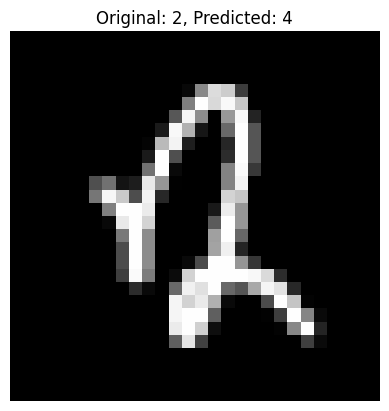

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(test_images))

# Get image and label
sample_image = test_images[index]
true_label = y_test[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input)    # gives probability from 0 to 9
predicted_label = np.argmax(prediction)           # gives the index of highest probability

# Print results
print("Original Label:", true_label)
print("Predicted Label:", predicted_label)

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Original: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()